# Problemas de Satisfacción de Restricciones (CSP)
## De Backtracking a AC-3

Este notebook estudia cómo modelar y resolver problemas en los que buscamos una asignación que satisfaga restricciones.

$$\text{Backtracking}\rightarrow\text{Forward Checking}\rightarrow\text{AC-3}$$

**Objetivos**

- Modelar un problema como $(X,D,C)$.
- Implementar Backtracking y Forward Checking.
- Comprender soporte y consistencia de arco.
- Implementar `revise()` y AC-3.
- Integrar AC-3 con Backtracking.
- Comparar el esfuerzo de búsqueda.

![Descripción](https://drive.google.com/uc?export=view&id=1opAXyVoZi8Orca1oSZ3zRk-vG_d868c1)

> 💡 **Idea central**  
> Un CSP no pregunta cuál solución es mejor. Pregunta si existe una asignación completa que satisfaga todas las restricciones.

In [ ]:
import time
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
plt.rcParams["figure.figsize"]=(8,5)
plt.rcParams["font.size"]=11

# 1. Definición

Un CSP se representa como:

$$\mathcal P=(X,D,C)$$

- $X$: variables.
- $D$: dominios posibles.
- $C$: restricciones.

Una solución asigna un valor a cada variable sin violar restricciones.

## CSP vs. optimización

| CSP | Optimización |
|---|---|
| Busca una solución válida | Busca la mejor solución |
| Variables, dominios y restricciones | Variables, restricciones y función objetivo |
| Las soluciones válidas pueden ser equivalentes | Las soluciones tienen diferente calidad |

# 2. Ejemplo: coloreo de mapas

```text
      A
     / \
    B---C
     \ /
      D
```

$$X=\{A,B,C,D\},\qquad D_i=\{Rojo,Verde,Azul\}$$

Para cada par vecino:

$$X_i\neq X_j$$

In [ ]:
variables=["A","B","C","D"]
neighbors={
    "A":{"B","C"},
    "B":{"A","C","D"},
    "C":{"A","B","D"},
    "D":{"B","C"},
}
colors=["Rojo","Verde","Azul"]
domains={v:set(colors) for v in variables}

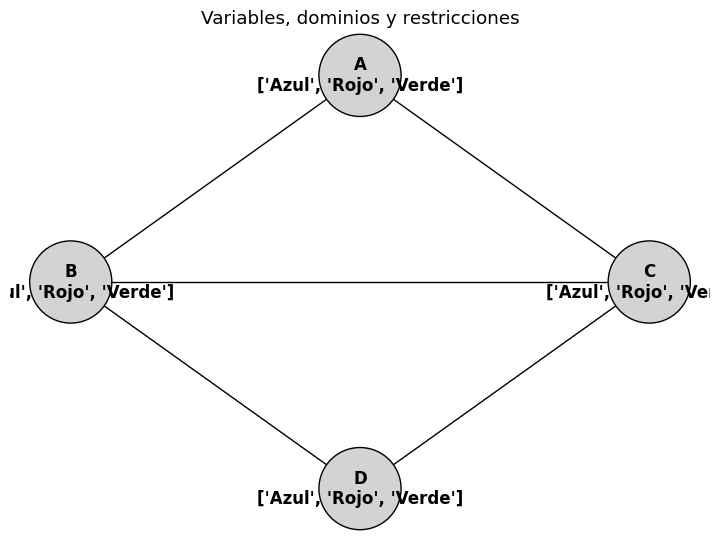

In [ ]:
def draw_map(assignment=None, domains=None, title="Mapa CSP"):
    assignment=assignment or {}
    pos={"A":(0,1),"B":(-1,0),"C":(1,0),"D":(0,-1)}
    palette={"Rojo":"lightcoral","Verde":"lightgreen","Azul":"lightskyblue"}
    g=nx.Graph(); g.add_nodes_from(variables)
    for x in variables:
        for y in neighbors[x]: g.add_edge(x,y)
    node_colors=[palette.get(assignment.get(n),"lightgray") for n in g.nodes]
    labels={}
    for n in g.nodes:
        if n in assignment: labels[n]=f"{n}\n{assignment[n]}"
        elif domains is not None: labels[n]=f"{n}\n{sorted(domains[n])}"
        else: labels[n]=n
    plt.figure(figsize=(7,5))
    nx.draw(g,pos,with_labels=True,labels=labels,node_size=3500,node_color=node_colors,
            edgecolors="black",font_weight="bold")
    plt.title(title); plt.axis("off"); plt.show()

draw_map(domains=domains,title="Variables, dominios y restricciones")

> 📝 **Actividad 1**  
> Modele un horario de exámenes como $(X,D,C)$. Identifique variables, dominios y restricciones; todavía no programe.

# 3. Representación general de un CSP binario

Una restricción binaria se evaluará con:

```python
constraint(Xi, value_i, Xj, value_j)
```

In [ ]:
class BinaryCSP:
    def __init__(self, variables, domains, neighbors, constraint):
        self.variables=list(variables)
        self.domains={v:set(vals) for v,vals in domains.items()}
        self.neighbors={v:set(vals) for v,vals in neighbors.items()}
        self.constraint=constraint
    def copy_domains(self):
        return {v:set(vals) for v,vals in self.domains.items()}

def different_values_constraint(xi,vi,xj,vj):
    return vi != vj

map_csp=BinaryCSP(variables,domains,neighbors,different_values_constraint)

# 4. Consistencia de una asignación parcial

Una asignación parcial es consistente cuando no viola restricciones entre variables ya asignadas.

In [ ]:
def is_consistent(csp, variable, value, assignment):
    for neighbor in csp.neighbors[variable]:
        if neighbor in assignment:
            if not csp.constraint(variable,value,neighbor,assignment[neighbor]):
                return False
    return True

print(is_consistent(map_csp,"B","Verde",{"A":"Rojo"}))
print(is_consistent(map_csp,"B","Rojo",{"A":"Rojo"}))

True
False


# 5. Backtracking

Backtracking asigna una variable, prueba valores y retrocede cuando ninguna alternativa funciona.

En el peor caso:

$$O(d^n)$$

para $n$ variables y dominios de tamaño $d$.

```text
BACKTRACK(assignment)
    si assignment está completo: retornar assignment
    variable ← seleccionar variable no asignada
    para cada valor:
        si es consistente:
            asignar y llamar BACKTRACK
            si funciona: retornar resultado
            deshacer asignación
    retornar falla
```

{'A': 'Azul', 'B': 'Rojo', 'C': 'Verde', 'D': 'Azul'}
{'calls': 5, 'assignments_tested': 7, 'backtracks': 0, 'time_seconds': 1.914800000690775e-05}


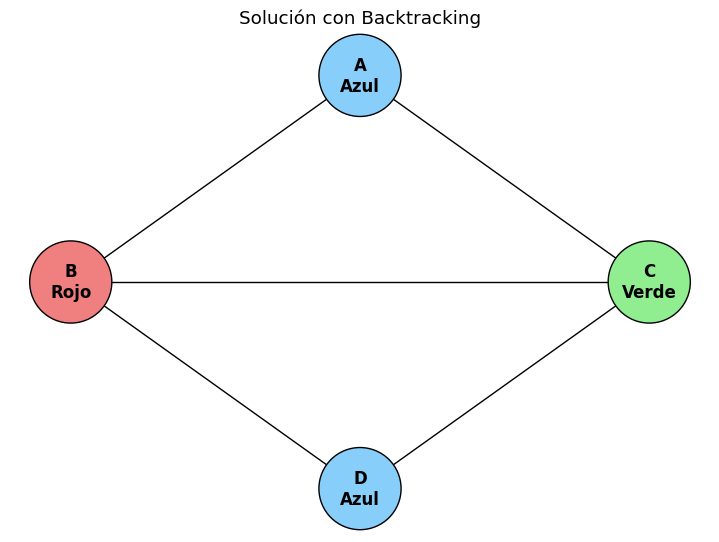

In [ ]:
def select_unassigned_variable(csp,assignment,domains):
    return next((v for v in csp.variables if v not in assignment),None)

def backtracking_search(csp):
    stats={"calls":0,"assignments_tested":0,"backtracks":0}
    def backtrack(assignment,domains):
        stats["calls"]+=1
        if len(assignment)==len(csp.variables): return assignment.copy()
        var=select_unassigned_variable(csp,assignment,domains)
        for value in sorted(domains[var]):
            stats["assignments_tested"]+=1
            if is_consistent(csp,var,value,assignment):
                assignment[var]=value
                result=backtrack(assignment,domains)
                if result is not None: return result
                assignment.pop(var)
        stats["backtracks"]+=1
        return None
    start=time.perf_counter(); sol=backtrack({},csp.copy_domains())
    stats["time_seconds"]=time.perf_counter()-start
    return sol,stats

solution_bt,stats_bt=backtracking_search(map_csp)
print(solution_bt); print(stats_bt)
draw_map(solution_bt,title="Solución con Backtracking")

> ⚠️ **Limitación**  
> Backtracking puede descubrir muy tarde que una variable futura quedó sin valores posibles.

# 6. Forward Checking

Después de asignar $A=Rojo$, Forward Checking elimina `Rojo` de los dominios de sus vecinos. Si algún dominio queda vacío, la rama falla inmediatamente.

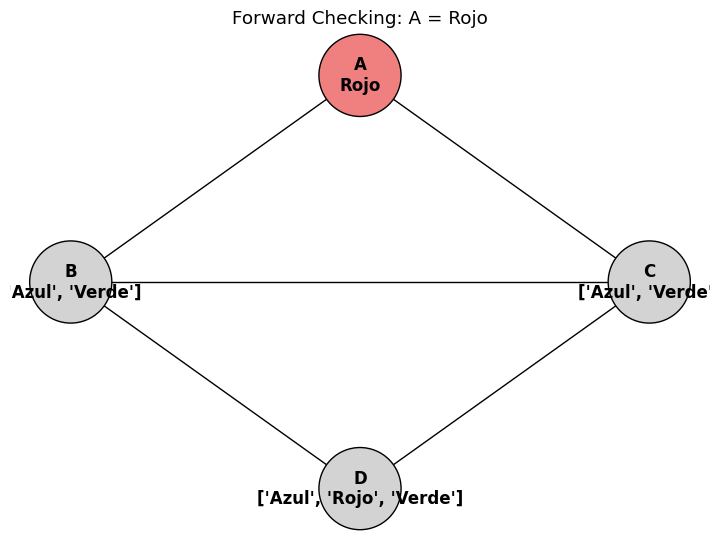

In [ ]:
def forward_check(csp,variable,value,assignment,domains):
    new_domains={v:set(vals) for v,vals in domains.items()}
    new_domains[variable]={value}
    for neighbor in csp.neighbors[variable]:
        if neighbor in assignment: continue
        remove={nv for nv in new_domains[neighbor]
                if not csp.constraint(variable,value,neighbor,nv)}
        new_domains[neighbor]-=remove
        if not new_domains[neighbor]: return None
    return new_domains

example_assignment={"A":"Rojo"}
after_fc=forward_check(map_csp,"A","Rojo",example_assignment,map_csp.copy_domains())
draw_map(example_assignment,after_fc,"Forward Checking: A = Rojo")

In [ ]:
def backtracking_with_forward_checking(csp):
    stats={"calls":0,"assignments_tested":0,"backtracks":0,"values_removed":0}
    def backtrack(assignment,domains):
        stats["calls"]+=1
        if len(assignment)==len(csp.variables): return assignment.copy()
        var=select_unassigned_variable(csp,assignment,domains)
        for value in sorted(domains[var]):
            stats["assignments_tested"]+=1
            if not is_consistent(csp,var,value,assignment): continue
            assignment[var]=value
            nd=forward_check(csp,var,value,assignment,domains)
            if nd is not None:
                stats["values_removed"]+=sum(map(len,domains.values()))-sum(map(len,nd.values()))
                result=backtrack(assignment,nd)
                if result is not None: return result
            assignment.pop(var)
        stats["backtracks"]+=1
        return None
    start=time.perf_counter(); sol=backtrack({},csp.copy_domains())
    stats["time_seconds"]=time.perf_counter()-start
    return sol,stats

solution_fc,stats_fc=backtracking_with_forward_checking(map_csp)
print(solution_fc); print(stats_fc)

{'A': 'Azul', 'B': 'Rojo', 'C': 'Verde', 'D': 'Azul'}
{'calls': 5, 'assignments_tested': 4, 'backtracks': 0, 'values_removed': 8, 'time_seconds': 5.9628999991900855e-05}


# 7. Consistencia de arco y soporte

El arco dirigido $(X_i,X_j)$ es consistente cuando cada valor de $D_i$ tiene al menos un valor compatible en $D_j$:

$$\forall x\in D_i,\ \exists y\in D_j:\ C_{ij}(x,y)$$

El valor $y$ es un **soporte** para $x$.

Ejemplo:

$$D_A=\{Rojo,Verde\},\qquad D_B=\{Rojo\},\qquad A\neq B$$

`Rojo` en $D_A$ no tiene soporte; `Verde` sí.

In [ ]:
def has_support(csp,xi,value_i,xj,domains):
    return any(csp.constraint(xi,value_i,xj,value_j) for value_j in domains[xj])

example_domains={
    "A":{"Rojo","Verde"},"B":{"Rojo"},
    "C":{"Rojo","Verde","Azul"},"D":{"Rojo","Verde","Azul"}}
for value in sorted(example_domains["A"]):
    print(value,has_support(map_csp,"A",value,"B",example_domains))

Rojo False
Verde True


# 8. `revise(Xi, Xj)`

Elimina de $D_i$ los valores que no tienen soporte en $D_j$. Devuelve si el dominio cambió.

In [ ]:
def revise(csp,domains,xi,xj):
    remove={value_i for value_i in domains[xi]
            if not has_support(csp,xi,value_i,xj,domains)}
    if remove:
        domains[xi]-=remove
        return True,remove
    return False,set()

demo={v:set(vals) for v,vals in example_domains.items()}
changed,removed=revise(map_csp,demo,"A","B")
print("Cambió:",changed,"Eliminados:",removed,"Nuevo D(A):",demo["A"])

Cambió: True Eliminados: {'Rojo'} Nuevo D(A): {'Verde'}


> 📝 **Actividad 2**  
> Implemente una versión propia de `revise()`: recorra $D_i$, busque soporte en $D_j$ y elimine valores sin soporte.

In [ ]:
# def revise_student(csp, domains, xi, xj):
#     revised = False
#     ...
#     return revised

# 9. AC-3

AC-3 mantiene una cola de arcos. Cuando `revise(Xi,Xj)` modifica $D_i$, se vuelven a insertar los arcos que pueden verse afectados.

```text
Q ← todos los arcos
mientras Q no esté vacía:
    (Xi,Xj) ← extraer arco
    si REVISE(Xi,Xj):
        si D(Xi) está vacío: retornar falso
        agregar (Xk,Xi) para vecinos Xk de Xi, excepto Xj
retornar verdadero
```

In [ ]:
def all_arcs(csp):
    return deque((xi,xj) for xi in csp.variables for xj in csp.neighbors[xi])

def ac3(csp,domains=None,queue=None,record_history=False):
    domains=csp.copy_domains() if domains is None else {v:set(vals) for v,vals in domains.items()}
    queue=all_arcs(csp) if queue is None else deque(queue)
    stats={"arcs_processed":0,"revisions":0,"values_removed":0}; history=[]
    while queue:
        xi,xj=queue.popleft(); stats["arcs_processed"]+=1
        changed,removed=revise(csp,domains,xi,xj)
        if record_history:
            history.append({"arc":(xi,xj),"removed":set(removed),
                            "domains":{v:set(vals) for v,vals in domains.items()},
                            "queue_size":len(queue)})
        if changed:
            stats["revisions"]+=1; stats["values_removed"]+=len(removed)
            if not domains[xi]: return False,domains,stats,history
            for xk in csp.neighbors[xi]-{xj}: queue.append((xk,xi))
    return True,domains,stats,history

## Ejemplo de propagación

$$D_A=\{Rojo\},\quad D_B=\{Rojo,Verde\},\quad D_C=\{Verde,Azul\}$$

Con restricciones de desigualdad, $A$ reduce $B$ y la reducción de $B$ se propaga hacia $C$.

In [ ]:
chain_csp=BinaryCSP(
    ["A","B","C"],
    {"A":{"Rojo"},"B":{"Rojo","Verde"},"C":{"Verde","Azul"}},
    {"A":{"B"},"B":{"A","C"},"C":{"B"}},
    different_values_constraint)
consistent,reduced,ac3_stats,history=ac3(chain_csp,record_history=True)
print("Consistente:",consistent); print("Dominios finales:",reduced); print(ac3_stats)

Consistente: True
Dominios finales: {'A': {'Rojo'}, 'B': {'Verde'}, 'C': {'Azul'}}
{'arcs_processed': 5, 'revisions': 2, 'values_removed': 2}


In [ ]:
def show_ac3_history(history):
    for step,item in enumerate(history,1):
        print(f"Paso {step}: arco {item['arc'][0]} → {item['arc'][1]}")
        print("  Eliminados:",sorted(item["removed"]))
        print("  Dominios:",{v:sorted(vals) for v,vals in item["domains"].items()})
        print("  Cola restante:",item["queue_size"])
        print("-"*50)
show_ac3_history(history)

Paso 1: arco A → B
  Eliminados: []
  Dominios: {'A': ['Rojo'], 'B': ['Rojo', 'Verde'], 'C': ['Azul', 'Verde']}
  Cola restante: 3
--------------------------------------------------
Paso 2: arco B → C
  Eliminados: []
  Dominios: {'A': ['Rojo'], 'B': ['Rojo', 'Verde'], 'C': ['Azul', 'Verde']}
  Cola restante: 2
--------------------------------------------------
Paso 3: arco B → A
  Eliminados: ['Rojo']
  Dominios: {'A': ['Rojo'], 'B': ['Verde'], 'C': ['Azul', 'Verde']}
  Cola restante: 1
--------------------------------------------------
Paso 4: arco C → B
  Eliminados: ['Verde']
  Dominios: {'A': ['Rojo'], 'B': ['Verde'], 'C': ['Azul']}
  Cola restante: 1
--------------------------------------------------
Paso 5: arco C → B
  Eliminados: []
  Dominios: {'A': ['Rojo'], 'B': ['Verde'], 'C': ['Azul']}
  Cola restante: 0
--------------------------------------------------


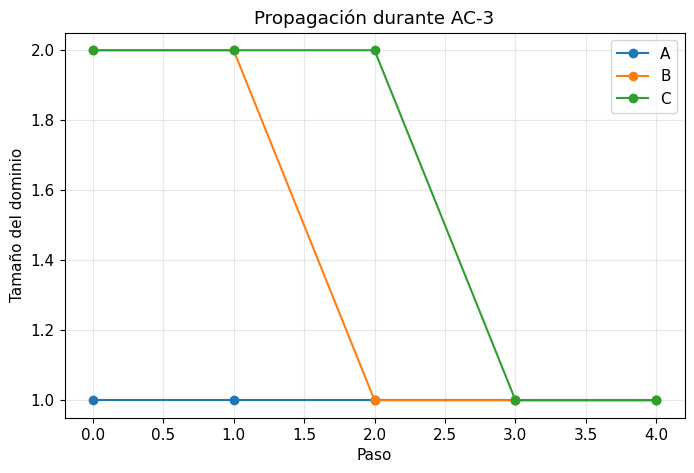

,Paso,Arco,A,B,C
0,0,A → B,1,2,2
1,1,B → C,1,2,2
2,2,B → A,1,1,2
3,3,C → B,1,1,1
4,4,C → B,1,1,1


In [ ]:
rows=[]
for step,item in enumerate(history):
    row={"Paso":step,"Arco":f"{item['arc'][0]} → {item['arc'][1]}"}
    row.update({v:len(item["domains"][v]) for v in chain_csp.variables}); rows.append(row)
history_df=pd.DataFrame(rows)
ax=history_df.set_index("Paso")[chain_csp.variables].plot(marker="o")
ax.set_ylabel("Tamaño del dominio"); ax.set_title("Propagación durante AC-3"); ax.grid(alpha=.3)
plt.show(); history_df

> 💡 **Diferencia clave**  
> Forward Checking mira desde la variable recién asignada. AC-3 continúa propagando reducciones por toda la red.

# 10. Backtracking + AC-3

Después de asignar $X_i=v$, reducimos $D_i$ a $\{v\}$ y ejecutamos AC-3 sobre los arcos $(X_j,X_i)$ de sus vecinos.

{'A': 'Azul', 'B': 'Rojo', 'C': 'Verde', 'D': 'Azul'}
{'calls': 5, 'assignments_tested': 4, 'backtracks': 0, 'ac3_calls': 5, 'arcs_processed': 23, 'values_removed': 5, 'time_seconds': 5.688499999223495e-05}


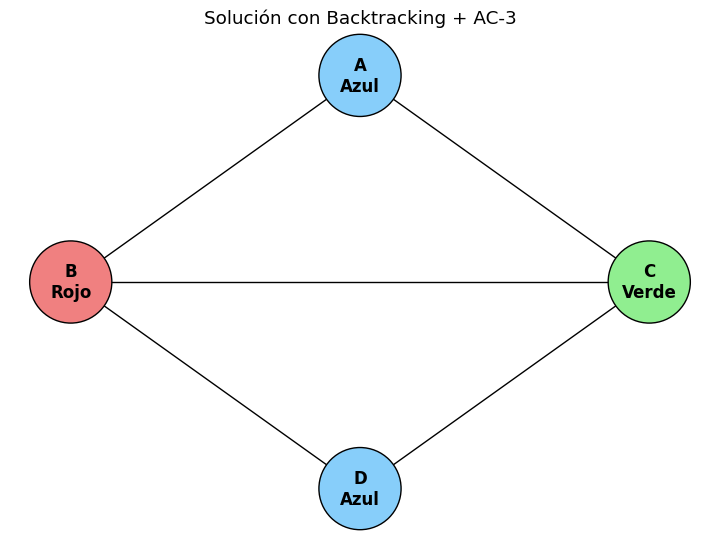

In [ ]:
def backtracking_with_ac3(csp):
    stats={"calls":0,"assignments_tested":0,"backtracks":0,
           "ac3_calls":0,"arcs_processed":0,"values_removed":0}
    def backtrack(assignment,domains):
        stats["calls"]+=1
        if len(assignment)==len(csp.variables): return assignment.copy()
        var=select_unassigned_variable(csp,assignment,domains)
        for value in sorted(domains[var]):
            stats["assignments_tested"]+=1
            if not is_consistent(csp,var,value,assignment): continue
            new_assignment=assignment.copy(); new_assignment[var]=value
            nd={v:set(vals) for v,vals in domains.items()}; nd[var]={value}
            queue=deque((neighbor,var) for neighbor in csp.neighbors[var]
                        if neighbor not in new_assignment)
            stats["ac3_calls"]+=1
            ok,rd,s,_=ac3(csp,nd,queue)
            stats["arcs_processed"]+=s["arcs_processed"]
            stats["values_removed"]+=s["values_removed"]
            if ok:
                result=backtrack(new_assignment,rd)
                if result is not None: return result
        stats["backtracks"]+=1
        return None
    stats["ac3_calls"]+=1
    ok,initial,s,_=ac3(csp)
    stats["arcs_processed"]+=s["arcs_processed"]; stats["values_removed"]+=s["values_removed"]
    start=time.perf_counter(); sol=backtrack({},initial) if ok else None
    stats["time_seconds"]=time.perf_counter()-start
    return sol,stats

solution_ac3,stats_ac3=backtracking_with_ac3(map_csp)
print(solution_ac3); print(stats_ac3)
draw_map(solution_ac3,title="Solución con Backtracking + AC-3")

# 11. Comparación

En problemas pequeños las diferencias pueden ser reducidas. En problemas muy restringidos, la inferencia puede podar grandes partes del árbol.

In [ ]:
comparison=pd.DataFrame([
    {"Algoritmo":"Backtracking",**stats_bt},
    {"Algoritmo":"BT + Forward Checking",**stats_fc},
    {"Algoritmo":"BT + AC-3",**stats_ac3},
])
cols=["Algoritmo","calls","assignments_tested","backtracks","time_seconds"]
comparison[cols]

,Algoritmo,calls,assignments_tested,backtracks,time_seconds
0,Backtracking,5,7,0,0.000019
1,BT + Forward Checking,5,4,0,0.000060
2,BT + AC-3,5,4,0,0.000057


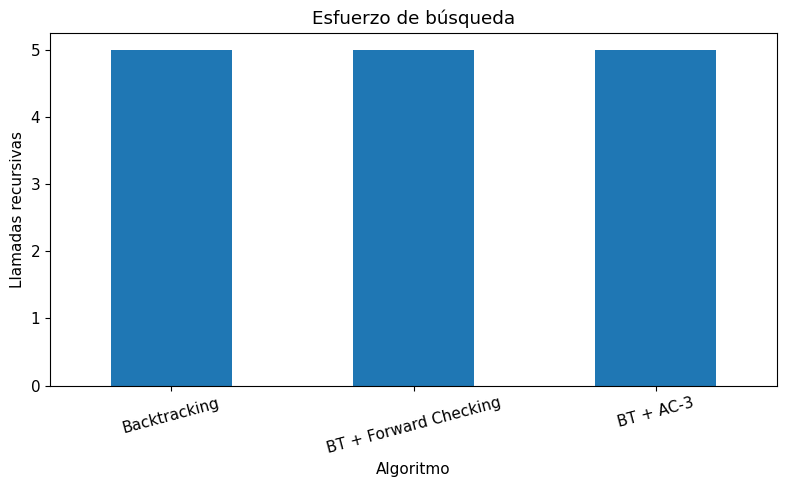

In [ ]:
ax=comparison.plot(x="Algoritmo",y="calls",kind="bar",legend=False)
ax.set_ylabel("Llamadas recursivas"); ax.set_title("Esfuerzo de búsqueda")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

> ⚠️ **AC-3 no siempre resuelve el CSP.**  
> Puede detectar inconsistencias o reducir dominios, pero si quedan dominios con varios valores todavía se necesita búsqueda.

# 12. Heurísticas

- **MRV:** escoge la variable con menor dominio, $\arg\min |D_i|$.
- **Degree:** ante un empate, escoge la variable que restringe más vecinos.
- **LCV:** prueba primero el valor que elimina menos alternativas.

Estas heurísticas cambian el orden de búsqueda, no el conjunto de soluciones.

# 13. Bonus: Sudoku 4×4

Variables: $X_{r,c}$. Dominios: $\{1,2,3,4\}$. Restricciones: valores diferentes en filas, columnas y bloques $2\times2$.

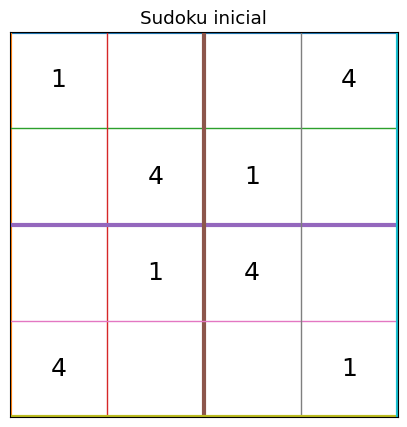

In [ ]:
def create_sudoku_4x4_csp(board):
    vars_=[(r,c) for r in range(4) for c in range(4)]
    dom={(r,c):({board[r][c]} if board[r][c] else set(range(1,5))) for r,c in vars_}
    neigh={v:set() for v in vars_}
    for r,c in vars_:
        for rr,cc in vars_:
            if (r,c)==(rr,cc): continue
            if r==rr or c==cc or (r//2==rr//2 and c//2==cc//2): neigh[(r,c)].add((rr,cc))
    return BinaryCSP(vars_,dom,neigh,different_values_constraint)

def draw_sudoku(board,title="Sudoku 4×4"):
    fig,ax=plt.subplots(figsize=(5,5)); ax.set_xlim(0,4); ax.set_ylim(0,4); ax.invert_yaxis()
    for i in range(5):
        lw=3 if i%2==0 else 1
        ax.plot([0,4],[i,i],linewidth=lw); ax.plot([i,i],[0,4],linewidth=lw)
    for r in range(4):
        for c in range(4):
            if board[r][c]: ax.text(c+.5,r+.5,str(board[r][c]),ha="center",va="center",fontsize=18)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title); plt.show()

sudoku_board=[[1,0,0,4],[0,4,1,0],[0,1,4,0],[4,0,0,1]]
draw_sudoku(sudoku_board,"Sudoku inicial")

{'calls': 17, 'assignments_tested': 16, 'backtracks': 0, 'ac3_calls': 17, 'arcs_processed': 306, 'values_removed': 23, 'time_seconds': 0.0003242629999959945}


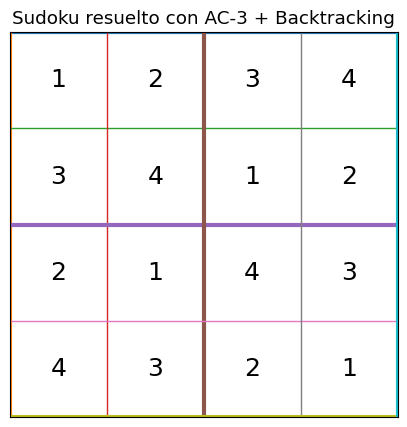

In [ ]:
sudoku_csp=create_sudoku_4x4_csp(sudoku_board)
sudoku_solution,sudoku_stats=backtracking_with_ac3(sudoku_csp)
print(sudoku_stats)
if sudoku_solution:
    solved=[[0]*4 for _ in range(4)]
    for (r,c),value in sudoku_solution.items(): solved[r][c]=value
    draw_sudoku(solved,"Sudoku resuelto con AC-3 + Backtracking")

# 14. Actividades

## Actividad 3 — Predicción

$$D_A=\{1\},\quad D_B=\{1,2\},\quad D_C=\{2,3\}$$

con $A\neq B$ y $B\neq C$. Prediga los dominios finales de AC-3 antes de ejecutar código.

## Actividad 4 — AC-3

Implemente `ac3_student()` con `deque`, `revise()`, detección de dominios vacíos y reinserción de arcos.

## Actividad 5 — Medición

Compare Backtracking, Forward Checking y AC-3 usando llamadas, asignaciones probadas, retrocesos, valores eliminados y tiempo.

## Actividad 6 — MRV

Modifique `select_unassigned_variable()` para escoger la variable no asignada con el dominio más pequeño.

## Actividad 7 — Reto

Modele y resuelva uno: horarios, salones, asignación de tareas, otro mapa o un nuevo Sudoku 4×4.

In [ ]:
# def ac3_student(csp, domains=None):
#     ...
#     return consistent, domains

# def select_unassigned_variable_mrv(csp, assignment, domains):
#     ...

# 15. Resumen

```text
Backtracking
    ↓
Forward Checking
    ↓
Consistencia de arco
    ↓
AC-3
    ↓
Backtracking + AC-3
```

> **La inferencia reduce el espacio de búsqueda antes de explorarlo.**